# Question 3 — Custom Histogram Equalization on Runway Image

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def show_gray(img, title=''):
    plt.figure(figsize=(6, 5))
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

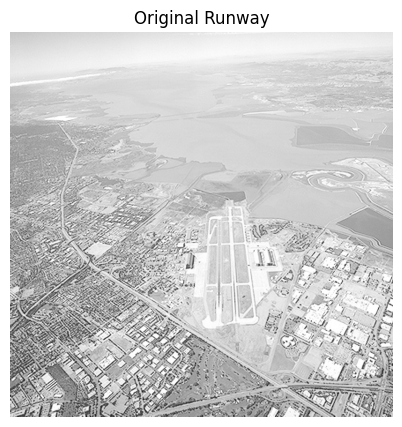

In [2]:
runway = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert runway is not None
show_gray(runway, 'Original Runway')

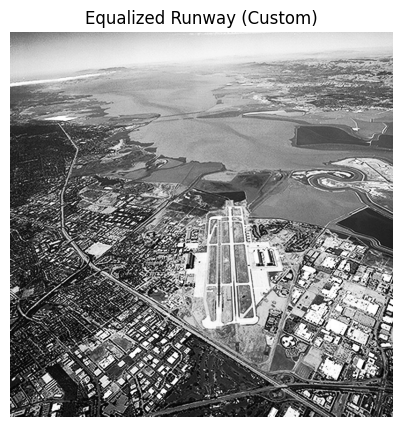

In [3]:
# Custom histogram equalization
# Formula: s_k = (L-1) * CDF(r_k) / (M*N)
def my_hist_equalization(img):
    hist  = np.bincount(img.flatten(), minlength=256)  # histogram
    cdf   = np.cumsum(hist / hist.sum())               # normalized CDF
    lut   = np.floor(255 * cdf).astype(np.uint8)       # mapping
    return lut[img]                                     # apply via indexing

runway_eq = my_hist_equalization(runway)
show_gray(runway_eq, 'Equalized Runway (Custom)')

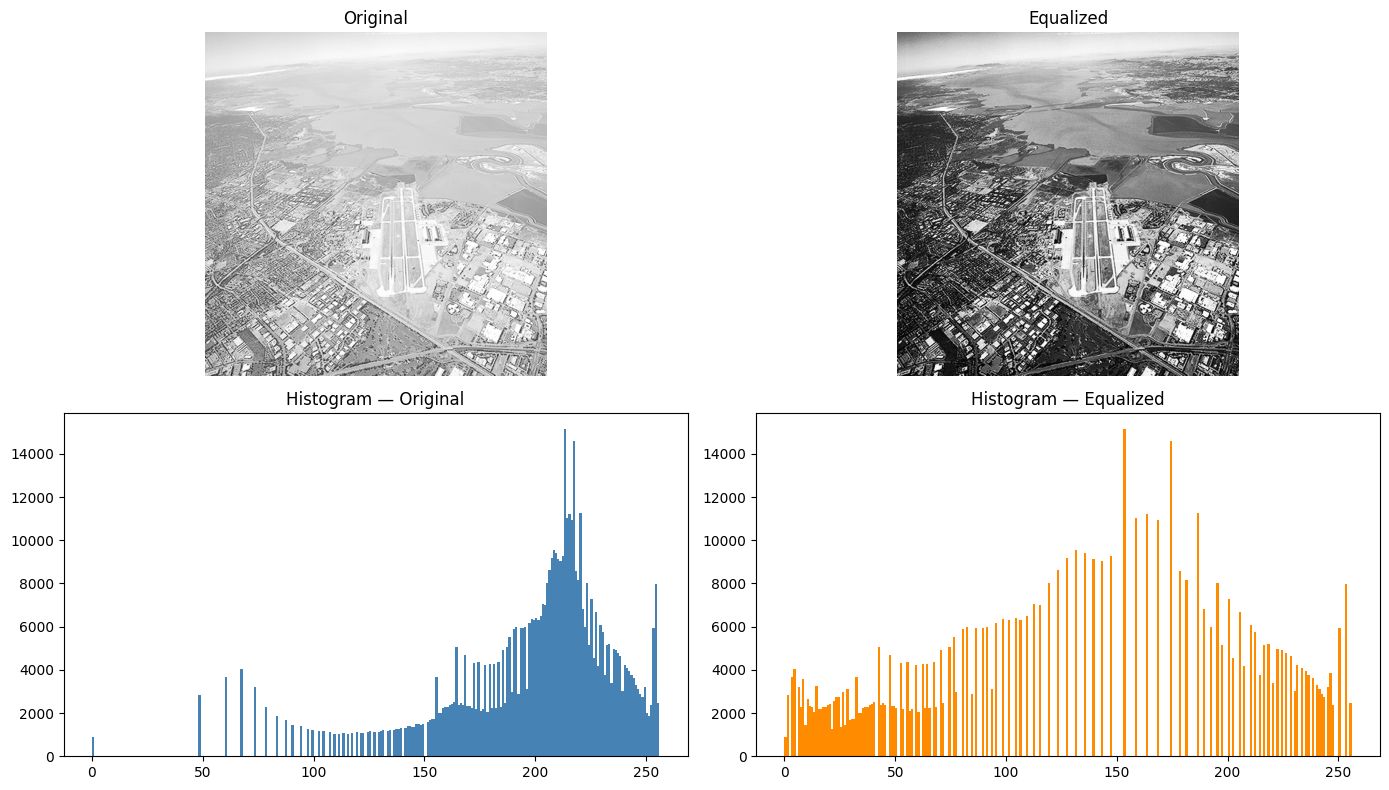

In [5]:
# Compare histograms before and after
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].imshow(runway,    cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original'); axes[0, 0].axis('off')
axes[0, 1].imshow(runway_eq, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Equalized'); axes[0, 1].axis('off')

axes[1, 0].hist(runway.ravel(),    bins=256, range=[0,256], color='steelblue')
axes[1, 0].set_title('Histogram — Original')
axes[1, 1].hist(runway_eq.ravel(), bins=256, range=[0,256], color='darkorange')
axes[1, 1].set_title('Histogram — Equalized')

plt.tight_layout()
plt.savefig('outputs/q3_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Verify against OpenCV's built-in
runway_cv = cv.equalizeHist(runway)
diff = np.abs(runway_eq.astype(int) - runway_cv.astype(int))
print('Max pixel difference vs cv.equalizeHist():', diff.max())

Max pixel difference vs cv.equalizeHist(): 1
